**Table of contents**<a id='toc0_'></a>    
1. [Desarrollo iterativo de prompts](#toc1_)    
1.1. [Setup](#toc1_1_)    
1.2. [Marketing de productos](#toc1_2_)    
1.2.1. [Primer prompt de marketing](#toc1_2_1_)    
1.2.2. [Problema 1: El texto es demasiado largo.](#toc1_2_2_)    
1.2.3. [Problema 2: El texto no es lo suficientemente específico ni dirigido a un público objetivo.](#toc1_2_3_)    
1.2.4. [Problema 3: La descripción necesita una tabla de dimensiones del producto.](#toc1_2_4_)    
1.2.5. [Cargamos la librería de Python que nos permite ver el contenido de una variable en formato HTML](#toc1_2_5_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Desarrollo iterativo de prompts](#toc0_)

En esta lección, analizará y perfeccionará de forma iterativa sus indicaciones para generar textos de marketing a partir de la ficha de un producto.

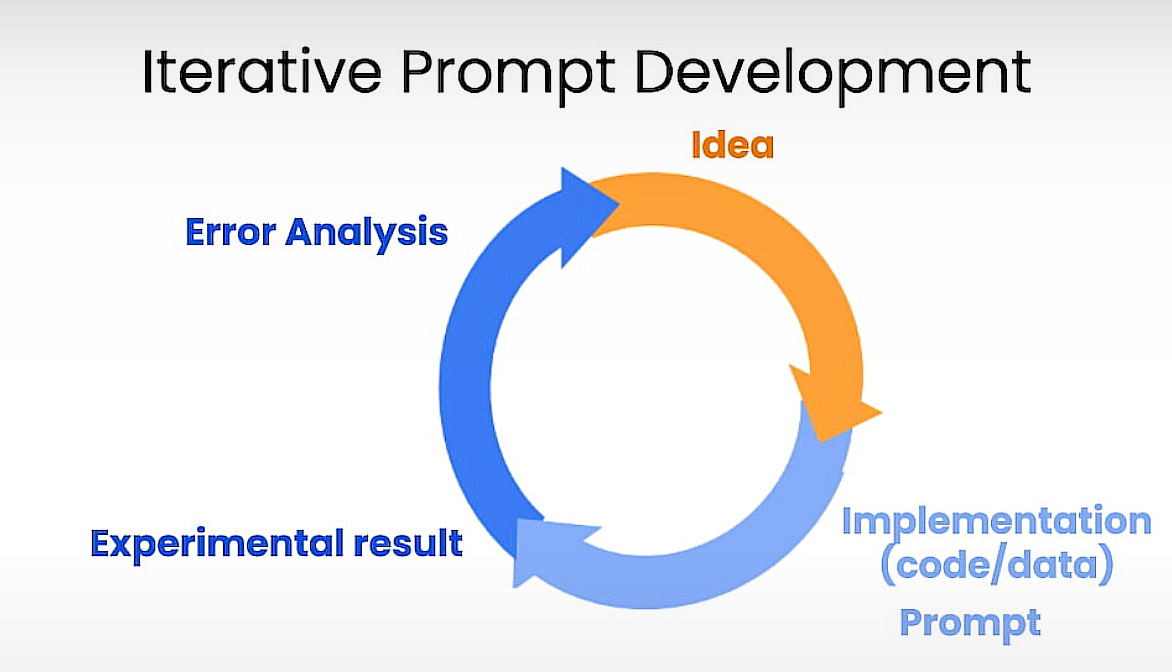

## 1.1. <a id='toc1_1_'></a>[Setup](#toc0_)

In [1]:
import openai
import os
from IPython.display import Markdown
import requests
import json

from dotenv import load_dotenv
load_dotenv()

openai.api_key = os.getenv("OPENAI_API_KEY")
auth_token = os.getenv("AUTH_TOKEN")


headers = {
  'Content-Type': 'application/json',
  'Authorization': f"Bearer {auth_token}"
}

url = 'https://api.awanllm.com/v1/chat/completions' # URL for the API
# Función para llamar a la API de LLMCloud para preguntarle a LLAMA
def preguntar_llama(sys_prompt, prompt):
    payload = json.dumps({
        "model": "Meta-Llama-3-8B-Instruct",
        "messages": [
            {"role": "system", "content": sys_prompt},
            {"role": "user", "content": prompt}
        ],
      })
    return requests.request("POST", url, headers=headers, data=payload).json()['choices'][0]['message']['content']

client = openai.OpenAI()

def get_completion(prompt, model="gpt-3.5-turbo-0125"):
    messages = [{"role": "user", "content": prompt}]
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0.1,
        max_tokens=512,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0
    )
    return response.choices[0].message.content

## 1.2. <a id='toc1_2_'></a>[Marketing de productos](#toc0_)

In [2]:
hoja_informativa_mesa = """
VISIÓN GENERAL
- Parte de una hermosa familia de muebles de estilo rústico, incluyendo sillas, bancos, armarios y más.
- Varias opciones de acabado de madera y estilos de patas.
- Disponible con o sin estante inferior para almacenamiento.
- Adecuado para entornos domésticos o empresariales.
- Calificado para uso en contratos.

CONSTRUCCIÓN
- Construcción en madera maciza.
- Diseño resistente y duradero.

DIMENSIONES
- ANCHO 80 CM
- LARGO 160 CM
- ALTURA 75 CM

OPCIONES
- Elección del acabado de madera: natural, teñida, desgastada, etc.
- Opciones de estilo de patas: rectas, cónicas, torneadas, etc.
- Estante inferior opcional para almacenamiento.

MATERIALES
TABLERO Y PATAS
- Madera maciza (nogal, roble, cedro, etc.)

PAÍS DE ORIGEN
- Grecia
"""


### 1.2.1. <a id='toc1_2_1_'></a>[Primer prompt de marketing](#toc0_)

In [3]:
prompt = f"""
Tu tarea consiste en ayudar a un equipo de marketing a crear una descripción de un producto para un sitio web en una ficha técnica.

Escriba una descripción del producto basada en la información proporcionada en la ficha técnica delimitada por tres comillas.

Ficha técnica: ```{hoja_informativa_mesa}```
"""
response = get_completion(prompt)
display(Markdown(f"### Descripción del producto de GPT\n{response}"))
print("\n---------------------------------------------\n")
display(Markdown(f"### Descripción del producto de LLAMA\n{preguntar_llama('Eres un asistente de IA cuyo trabajo es responder a lo que te está pidiendo el usuario de la forma más fiel al prompt sin preámbulos explicativos ni resúmenes finales.', prompt)}"))

### Descripción del producto de GPT
"Introducimos nuestra mesa de comedor de la hermosa familia de muebles de estilo rústico, perfecta para cualquier hogar o negocio. Con varias opciones de acabado de madera y estilos de patas, esta mesa está disponible en dimensiones de 80 cm de ancho, 160 cm de largo y 75 cm de altura. Construida en madera maciza de alta calidad, esta mesa es resistente y duradera. Puedes elegir entre diferentes acabados de madera, estilos de patas y la opción de agregar un estante inferior para almacenamiento. Hecha con madera maciza de nogal, roble, cedro, entre otros, esta mesa de comedor tiene su origen en Grecia y está calificada para uso en contratos. ¡Añade un toque de elegancia rústica a tu espacio con nuestra mesa de comedor!"


---------------------------------------------



### Descripción del producto de LLAMA
«La mesa de estilo rústico es parte de una colección de muebles diseñados para brindar un toque auténtico y acogedor a cualquier espacio. Fabricada con madera maciza, esta mesa ofrece resistencia y durabilidad gracias a su construcción sólida. Dispone de varias opciones de acabado de madera, como natural, teñida o desgastada, y diferentes estilos de patas, desde las clásicas patas rectas hasta las decorativas patas cónicas. Además, cuenta con un estante inferior disponible para almacenar objetos y documentos. Con medidas de 80 cm de ancho, 160 cm de largo y 75 cm de altura, esta mesa es perfecta para espacios domésticos o empresariales. El país de origen es Grecia, donde se utiliza materia prima de alta calidad, como nogal, roble y cedro. La mesa es apta para uso en contratos y puede ser personalizada según las necesidades específicas de cada cliente.».

### 1.2.2. <a id='toc1_2_2_'></a>[Problema 1: El texto es demasiado largo.](#toc0_)

Podemos especificar la longitud del texto que queremos generar ya sea mediante caracteres, palabras o párrafos. En este caso, vamos a especificar la longitud en frases.

In [4]:
prompt = f"""
Tu tarea consiste en ayudar a un equipo de marketing a crear una descripción de un producto para un sitio web en una ficha técnica.

Escriba una descripción del producto basada en la información proporcionada en la ficha técnica delimitada por tres comillas.

Usa como mucho 3-4 oraciones para describir el producto.

Ficha técnica: ```{hoja_informativa_mesa}```
"""
response = get_completion(prompt)
display(Markdown(f"### Descripción del producto de GPT\n{response}"))
print("\n---------------------------------------------\n")
display(Markdown(f"### Descripción del producto de LLAMA\n{preguntar_llama('Eres un asistente de IA cuyo trabajo es responder a lo que te está pidiendo el usuario de la forma más fiel al prompt sin preámbulos explicativos ni resúmenes finales.', prompt)}"))

### Descripción del producto de GPT
"Presentamos nuestra mesa de comedor de la hermosa familia de muebles de estilo rústico, perfecta para cualquier hogar u oficina. Construida en madera maciza y disponible en diferentes acabados y estilos de patas, esta mesa es resistente y duradera. Con dimensiones de 80 cm de ancho, 160 cm de largo y 75 cm de altura, esta mesa ofrece la opción de un estante inferior para almacenamiento adicional. Fabricada en Grecia con materiales de alta calidad, esta mesa es una adición elegante y funcional a cualquier espacio."


---------------------------------------------



### Descripción del producto de LLAMA
"El mobiliario rústico 'X' es una pieza de estilo tradicional construida con materiales nobles y diseño resistente. Con varias opciones de acabado de madera y estilos de patas, este producto se adapta perfectamente a entornos domésticos o empresariales. Disponible con o sin estante inferior para almacenamiento, ofrece una solución práctica y versátil para cualquier necesidad."

### 1.2.3. <a id='toc1_2_3_'></a>[Problema 2: El texto no es lo suficientemente específico ni dirigido a un público objetivo.](#toc0_)

Vamos a añadir una sección de texto que enfoque la descripción del producto y a generar un identificador de producto al final de la descripción.

In [5]:
prompt = f"""
Tu tarea consiste en ayudar a un equipo de marketing a crear una descripción de un producto para un sitio web en una ficha técnica.

Escriba una descripción del producto basada en la información proporcionada en la ficha técnica delimitada por tres comillas.

La descripción está destinada a los minoristas de muebles, por lo que debe ser de carácter técnico y centrarse en los materiales con los que está fabricado el producto.

Al final de la descripción, genera un ID del producto de 7 caracteres.

Usa como mucho 3-4 oraciones para describir el producto.

Ficha técnica: ```{hoja_informativa_mesa}```
"""
response = get_completion(prompt)
display(Markdown(f"### Descripción del producto de GPT\n{response}"))
print("\n---------------------------------------------\n")
display(Markdown(f"### Descripción del producto de LLAMA\n{preguntar_llama('Eres un asistente de IA cuyo trabajo es responder a lo que te está pidiendo el usuario de la forma más fiel al prompt sin preámbulos explicativos ni resúmenes finales.', prompt)}"))

### Descripción del producto de GPT
"Presentamos nuestra mesa de comedor de la hermosa familia de muebles de estilo rústico, construida en madera maciza de alta calidad. Con opciones de acabado de madera y estilos de patas personalizables, esta mesa es resistente y duradera, perfecta para entornos domésticos o empresariales. Disponible con o sin estante inferior para almacenamiento, este producto versátil es una adición elegante a cualquier espacio. ¡ID del producto: MDRGRC1!"


---------------------------------------------



### Descripción del producto de LLAMA
"El producto es un mueble de estilo rústico construido en madera maciza, con opciones de acabado de madera natural, teñida, desgastada, etc. y diferentes estilos de patas, incluyendo rectas, cónicas y torneadas. También cuenta con estante inferior disponible para almacenamiento. Fabricado en Grecia utilizando madera maciza de nogal, roble o cedro. ID del producto: GRST0149."

### 1.2.4. <a id='toc1_2_4_'></a>[Problema 3: La descripción necesita una tabla de dimensiones del producto.](#toc0_)

Vamos a pedirle al modelo que extraiga las dimensiones del producto y las incluya en la descripción en forma de tabla, para ello le diremos que nos devuela la respuesta en formato HTML.

In [6]:
prompt = f"""
Tu tarea consiste en ayudar a un equipo de marketing a crear una descripción de un producto para un sitio web en una ficha técnica.

Escriba una descripción del producto basada en la información proporcionada en la ficha técnica delimitada por tres comillas.

La descripción está destinada a los minoristas de muebles, por lo que debe ser de carácter técnico y centrarse en los materiales con los que está fabricado el producto.

Al final de la descripción, genera un ID del producto de 7 caracteres.

Usa como mucho 3-4 oraciones para describir el producto.

Después de la descripción, incluye una tabla que de la información de las dimensiones del producto. La tabla debe tener 3 columnas: Ancho, Largo y Altura y dos filas: una para los títulos de las columnas y otra para los valores de las dimensiones. Da las dimensiones en centímetros.

Devuelve toda la respuesta en formato HTLM.

Ficha técnica: ```{hoja_informativa_mesa}```
"""
response = get_completion(prompt)
display(Markdown(f"### Descripción del producto de GPT\n{response}"))
print("\n---------------------------------------------\n")
display(Markdown(f"### Descripción del producto de LLAMA\n{preguntar_llama('Eres un asistente de IA cuyo trabajo es responder a lo que te está pidiendo el usuario de la forma más fiel al prompt sin preámbulos explicativos ni resúmenes finales.', prompt)}"))

### Descripción del producto de GPT
```html
<!DOCTYPE html>
<html>
<head>
<title>Descripción del Producto</title>
</head>
<body>

<h2>Descripción del Producto:</h2>
<p>"Este elegante y resistente mesa de comedor forma parte de una hermosa familia de muebles de estilo rústico. Fabricada en madera maciza de alta calidad, esta mesa está disponible en varias opciones de acabado de madera y estilos de patas. Puede elegir entre tener o no un estante inferior para almacenamiento. Perfecta para entornos domésticos o empresariales, esta mesa es adecuada para uso en contratos."</p>

<table border="1">
  <tr>
    <th>Ancho</th>
    <th>Largo</th>
    <th>Altura</th>
  </tr>
  <tr>
    <td>80 cm</td>
    <td>160 cm</td>
    <td>75 cm</td>
  </tr>
</table>

<p>ID del Producto: ABC1234</p>

</body>
</html>
```


---------------------------------------------



### Descripción del producto de LLAMA
<p>
El producto es un elemento de mobiliario rústico construido en madera maciza, diseñado para entornos domésticos o empresariales. Está disponible con diferentes opciones de acabado de madera y estilos de patas, permitiendo adaptarlo a diferentes estilos y necesidades. También se puede elegir entre una configuración con o sin estante inferior para almacenamiento adicional.
</p>

<table>
  <tr>
    <th>Ancho</th>
    <th>Largo</th>
    <th>Altura</th>
  </tr>
  <tr>
    <td>80 cm</td>
    <td>160 cm</td>
    <td>75 cm</td>
  </tr>
</table>

ID del producto: GTX456A

### 1.2.5. <a id='toc1_2_5_'></a>[Cargamos la librería de Python que nos permite ver el contenido de una variable en formato HTML](#toc0_)


In [7]:
from IPython.display import HTML, display
display(HTML(response))

Ancho,Largo,Altura
80 cm,160 cm,75 cm


## Tu turno de experimentar!
